# Import

In [31]:
import warnings
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd()
ROOT_DIR = next((p for p in [cwd, *cwd.parents] if (p / "lib").exists() and (p / "data").exists()), cwd)
LIB_DIR = ROOT_DIR / "lib"
DATA_DIR = ROOT_DIR / "data"

# lib ディレクトリを監視対象（import パス）に追加
if str(LIB_DIR) not in sys.path:
    sys.path.append(str(LIB_DIR))
from matplotlib_defaults import setup_matplotlib_defaults
from pandas_display import setup_pandas_display

# ignore warnings
warnings.filterwarnings("ignore")

setup_pandas_display()
setup_matplotlib_defaults()


# Functions

# Import data

In [32]:
path = DATA_DIR / "messi_goals_all.csv"
df = pd.read_csv(path)

# EDA

In [33]:
print(df.shape)
display(df.head())
df.info()
display(df.describe())
display(df.describe(include=["object"]))

# 型変換
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["is_penalty"] = pd.to_numeric(df["is_penalty"], errors="coerce").fillna(0).astype(bool)
df["is_official"] = pd.to_numeric(df["is_official"], errors="coerce").fillna(0).astype(bool)


# date列から年・月列を作成
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
display(df[["date", "year", "month"]].head())


(896, 16)


,goal_index,date,competition_code,competition,home_team,away_team,result,minute_raw,minute_base,minute_added,minute_total,what,how,is_penalty,is_official,source_url
0,1,2005-05-01,PRM La Liga,PRM La Liga,FC Barcelona,Albacete,2-0,90,90,0,90,NaN,Left foot,0,1,https://www.messistats.com/en/locationsscored
1,2,2005-11-02,EUR UEFA Champions League,EUR UEFA Champions League,FC Barcelona,Panathinaikos,5-0,34,34,0,34,Field goal,Left foot,0,1,https://www.messistats.com/en/locationsscored
2,3,2005-11-27,PRM La Liga,PRM La Liga,FC Barcelona,Racing Santander,4-1,52,52,0,52,Field goal,Left foot,0,1,https://www.messistats.com/en/locationsscored
3,4,2006-01-15,PRM La Liga,PRM La Liga,FC Barcelona,Athletic de Bilbao,2-1,51,51,0,51,Rebound,Left foot,0,1,https://www.messistats.com/en/locationsscored
4,5,2006-01-22,PRM La Liga,PRM La Liga,FC Barcelona,Alavés,2-0,81,81,0,81,Rebound,Left foot,0,1,https://www.messistats.com/en/locationsscored


<class 'pandas.DataFrame'>
RangeIndex: 896 entries, 0 to 895
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   goal_index        896 non-null    int64
 1   date              896 non-null    str  
 2   competition_code  896 non-null    str  
 3   competition       896 non-null    str  
 4   home_team         896 non-null    str  
 5   away_team         896 non-null    str  
 6   result            896 non-null    str  
 7   minute_raw        896 non-null    str  
 8   minute_base       896 non-null    int64
 9   minute_added      896 non-null    int64
 10  minute_total      896 non-null    int64
 11  what              618 non-null    str  
 12  how               896 non-null    str  
 13  is_penalty        896 non-null    int64
 14  is_official       896 non-null    int64
 15  source_url        896 non-null    str  
dtypes: int64(6), str(10)
memory usage: 112.1 KB


,goal_index,minute_base,minute_added,minute_total,is_penalty,is_official
count,896,896,896,896,896,896
mean,448.5,51.84,0.1306,51.97,0.125,0.942
std,258.8,26.02,0.6427,26.18,0.3309,0.2339
min,1,2,0,2,0,0
25%,224.8,30,0,30,0,1
50%,448.5,54,0,54,0,1
75%,672.2,75,0,75,0,1
max,896,110,7,110,1,1


,date,competition_code,competition,home_team,away_team,result,minute_raw,what,how,source_url
count,896,896,896,896,896,896,896,618,896,896
unique,589,28,28,111,128,47,102,5,6,1
top,2012-03-07,PRM La Liga,PRM La Liga,FC Barcelona,FC Barcelona,4-0,87,Field goal,Left foot,https://www.messistats.com/en/locationsscored
freq,5,474,474,400,272,60,22,360,752,896


,date,year,month
0,2005-05-01,2005,5
1,2005-11-02,2005,11
2,2005-11-27,2005,11
3,2006-01-15,2006,1
4,2006-01-22,2006,1


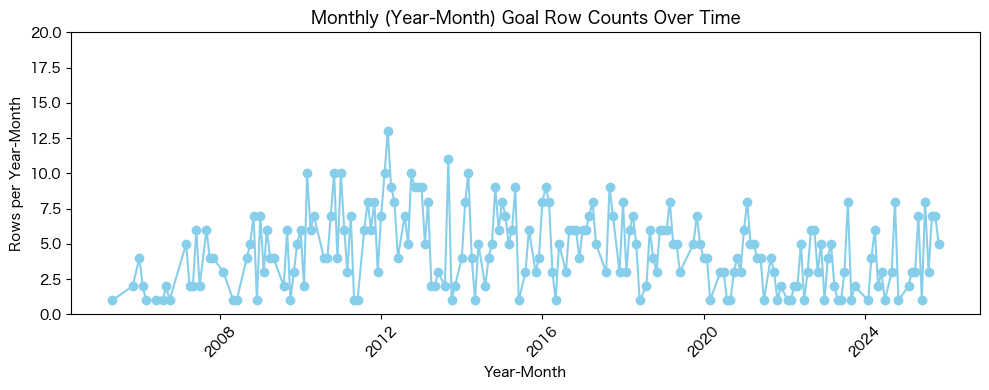

In [34]:
# 時系列（年-月）で行数をカウント
monthly_timeseries_counts = (
    df.assign(year_month=df["date"].dt.to_period("M"))
      .groupby("year_month")
      .size()
      .rename("count")
      .reset_index()
)
monthly_timeseries_counts["year_month"] = monthly_timeseries_counts["year_month"].dt.to_timestamp()

# 月次（年-月）行数のラインプロット
plt.figure(figsize=(10, 4))
plt.plot(
    monthly_timeseries_counts["year_month"],
    monthly_timeseries_counts["count"],
    marker="o",
    color="skyblue"
    )
plt.title("Monthly (Year-Month) Goal Row Counts Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Rows per Year-Month")
plt.ylim(0,20)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


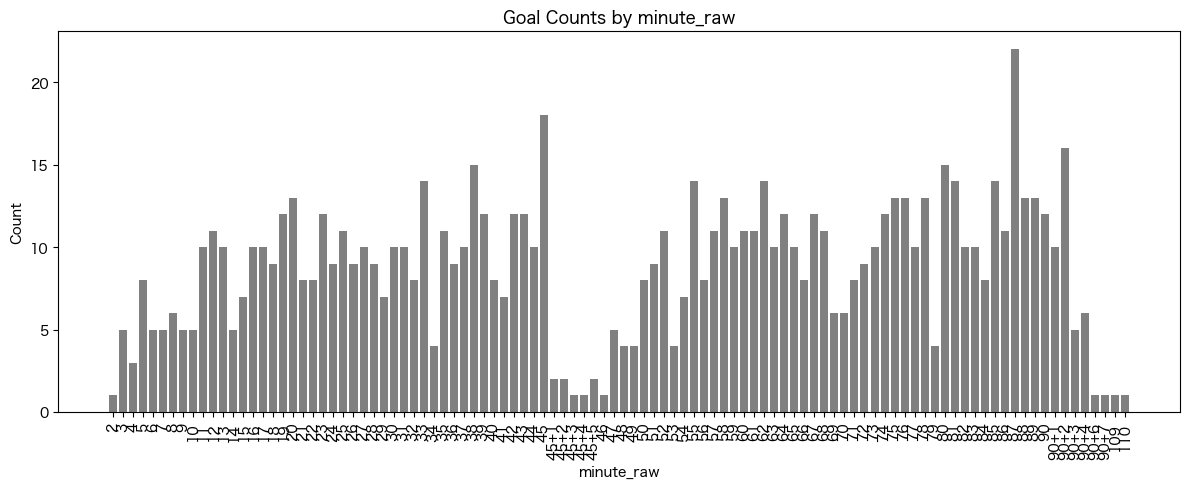

,minute_raw,count
0,2,1
1,3,5
2,4,3
3,5,8
4,6,5
...,...,...
97,90+4,6
98,90+6,1
99,90+7,1
100,109,1


In [36]:
# minute_raw列を値ごとに集計して棒グラフで可視化
minute_raw_counts = (
    df["minute_raw"]
    .dropna()
    .astype(str)
    .value_counts()
    .rename_axis("minute_raw")
    .reset_index(name="count")
)

# 例: 45+2 のような値も想定して表示順を調整
minute_raw_counts["base_minute"] = minute_raw_counts["minute_raw"].str.extract(r"^(\d+)")[0].astype(float)
minute_raw_counts["extra_minute"] = minute_raw_counts["minute_raw"].str.extract(r"\+(\d+)")[0].fillna(0).astype(float)
minute_raw_counts = minute_raw_counts.sort_values(["base_minute", "extra_minute", "minute_raw"]).reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.bar(minute_raw_counts["minute_raw"], minute_raw_counts["count"], color="gray")
plt.title("Goal Counts by minute_raw")
plt.xlabel("minute_raw")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

display(minute_raw_counts[["minute_raw", "count"]])
